Name: James Fisher
Date: April 11, 2026
Course: DDS-8555 (Predictive Analytics)
Assignment: Week 7, Kaggle Wine Dataset for Clustering

In [7]:
# Load libraries
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import zscore

# Load data
df = pd.read_csv("data/wine-clustering.csv")

print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Shape: (178, 13)

Columns:
['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']

First 5 rows:
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49              

In [8]:
# Assumption Checks
# Missing values
print("\nMissing values by column:")
print(df.isna().sum())

# Duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Data types
print("\nData types:")
print(df.dtypes)

# Summary stats
print("\nSummary statistics:")
print(df.describe().T)

# Outlier check using |z| > 3 on original variables
z_scores = np.abs(zscore(df, nan_policy="omit"))
if len(df) > 0:
    outlier_rows = np.where((z_scores > 3).any(axis=1))[0]
    print(f"\nRows with at least one |z| > 3: {len(outlier_rows)}")
    print(f"Row indices with potential outliers: {outlier_rows.tolist()[:25]}")
else:
    print("\nNo rows found.")

# Correlation matrix
corr = df.corr(numeric_only=True)
print("\nCorrelation matrix:")
print(corr.round(3))


Missing values by column:
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Number of duplicate rows: 0

Data types:
Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Ash_Alcanity            float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280                   float64
Proline                   int64
dtype: object

Summary statistics:
                      count        mean         std     min       25%  \
Alcohol               178.0   13.000618    0.811827   11

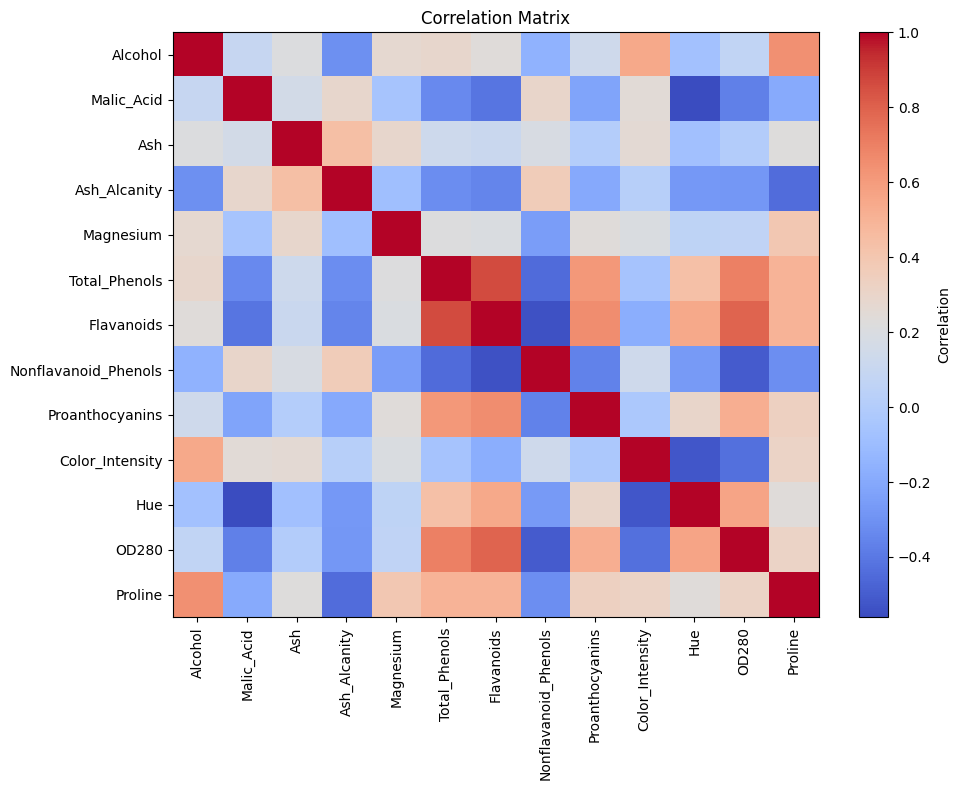

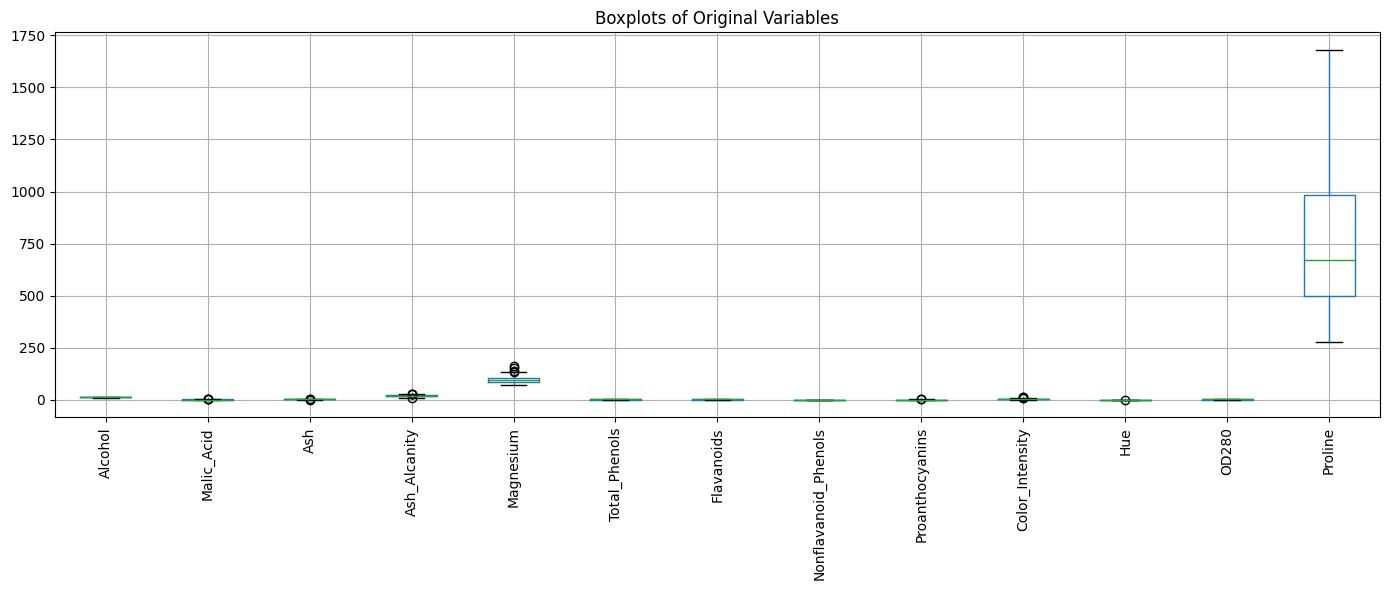

In [9]:
# Pre-PCA Visual CHecks
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Boxplots to inspect scale differences and outliers
plt.figure(figsize=(14, 6))
df.boxplot(rot=90)
plt.title("Boxplots of Original Variables")
plt.tight_layout()
plt.show()

In [10]:
# Standardize variable data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("\n====================")
print("STANDARDIZATION CHECK")
print("====================")
print("\nMeans after scaling (should be near 0):")
print(scaled_df.mean().round(4))
print("\nStd dev after scaling (should be near 1):")
print(scaled_df.std(ddof=0).round(4))


STANDARDIZATION CHECK

Means after scaling (should be near 0):
Alcohol                -0.0
Malic_Acid             -0.0
Ash                    -0.0
Ash_Alcanity           -0.0
Magnesium              -0.0
Total_Phenols           0.0
Flavanoids             -0.0
Nonflavanoid_Phenols    0.0
Proanthocyanins        -0.0
Color_Intensity         0.0
Hue                     0.0
OD280                   0.0
Proline                -0.0
dtype: float64

Std dev after scaling (should be near 1):
Alcohol                 1.0
Malic_Acid              1.0
Ash                     1.0
Ash_Alcanity            1.0
Magnesium               1.0
Total_Phenols           1.0
Flavanoids              1.0
Nonflavanoid_Phenols    1.0
Proanthocyanins         1.0
Color_Intensity         1.0
Hue                     1.0
OD280                   1.0
Proline                 1.0
dtype: float64


In [12]:
# Run PCA to retain at least 80% variance
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

print("\nExplained variance ratio by component:")
for i, var in enumerate(explained_variance_ratio, start=1):
    print(f"PC{i}: {var:.4f}")

print("\nCumulative explained variance:")
for i, cum_var in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {cum_var:.4f}")

print(f"\nNumber of principal components needed to retain at least 80% variance: {n_components_80}")


Explained variance ratio by component:
PC1: 0.3620
PC2: 0.1921
PC3: 0.1112
PC4: 0.0707
PC5: 0.0656
PC6: 0.0494
PC7: 0.0424
PC8: 0.0268
PC9: 0.0222
PC10: 0.0193
PC11: 0.0174
PC12: 0.0130
PC13: 0.0080

Cumulative explained variance:
PC1: 0.3620
PC2: 0.5541
PC3: 0.6653
PC4: 0.7360
PC5: 0.8016
PC6: 0.8510
PC7: 0.8934
PC8: 0.9202
PC9: 0.9424
PC10: 0.9617
PC11: 0.9791
PC12: 0.9920
PC13: 1.0000

Number of principal components needed to retain at least 80% variance: 5


In [13]:
# Fit PCA with components sufficient to retain 80% variance (n_components_80, which is 5 in this case)
pca = PCA(n_components=n_components_80)
X_pca = pca.fit_transform(X_scaled)

pca_columns = [f"PC{i}" for i in range(1, n_components_80 + 1)]
pca_scores_df = pd.DataFrame(X_pca, columns=pca_columns)

print("\nPCA loadings:")
loadings = pd.DataFrame(
    pca.components_.T,
    index=df.columns,
    columns=pca_columns
)
print(loadings.round(4))

print("\nVariance retained by selected PCs:")
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {var:.4f}")
print(f"Total retained variance: {pca.explained_variance_ratio_.sum():.4f}")


PCA loadings:
                         PC1     PC2     PC3     PC4     PC5
Alcohol               0.1443  0.4837 -0.2074 -0.0179 -0.2657
Malic_Acid           -0.2452  0.2249  0.0890  0.5369  0.0352
Ash                  -0.0021  0.3161  0.6262 -0.2142 -0.1430
Ash_Alcanity         -0.2393 -0.0106  0.6121  0.0609  0.0661
Magnesium             0.1420  0.2996  0.1308 -0.3518  0.7270
Total_Phenols         0.3947  0.0650  0.1462  0.1981 -0.1493
Flavanoids            0.4229 -0.0034  0.1507  0.1523 -0.1090
Nonflavanoid_Phenols -0.2985  0.0288  0.1704 -0.2033 -0.5007
Proanthocyanins       0.3134  0.0393  0.1495  0.3991  0.1369
Color_Intensity      -0.0886  0.5300 -0.1373  0.0659 -0.0764
Hue                   0.2967 -0.2792  0.0852 -0.4278 -0.1736
OD280                 0.3762 -0.1645  0.1660  0.1841 -0.1012
Proline               0.2868  0.3649 -0.1267 -0.2321 -0.1579

Variance retained by selected PCs:
PC1: 0.3620
PC2: 0.1921
PC3: 0.1112
PC4: 0.0707
PC5: 0.0656
Total retained variance: 0.8016


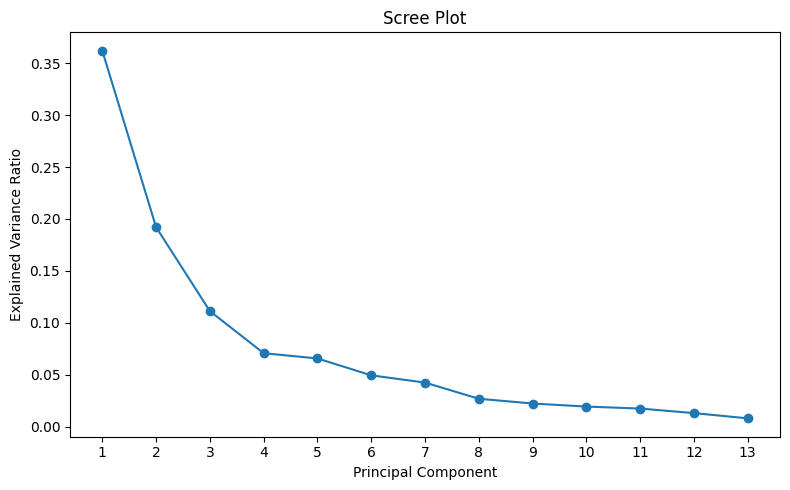

In [14]:
# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.tight_layout()
plt.show()

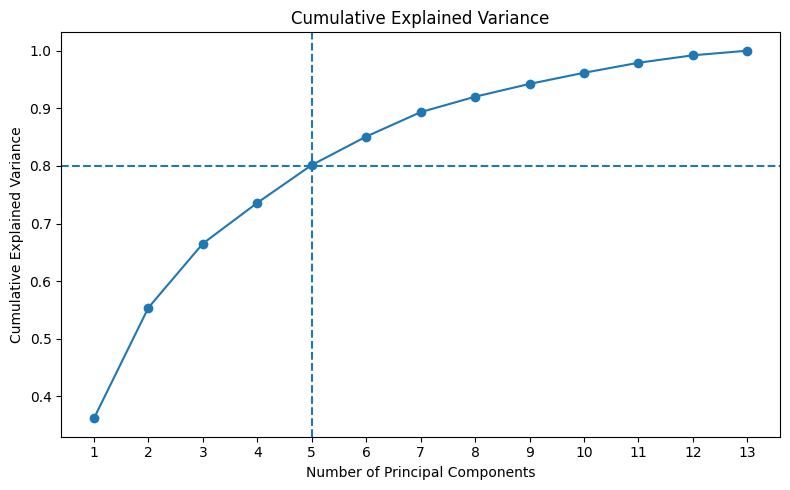

In [15]:
# Cumulative explained variance plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(0.80, linestyle="--")
plt.axvline(n_components_80, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.tight_layout()
plt.show()

    k    inertia  silhouette  calinski_harabasz  davies_bouldin
0   2  1201.1575      0.3239            95.7980          1.2748
1   3   825.0208      0.3691           109.2327          1.0933
2   4   723.9357      0.3256            90.6146          1.4194
3   5   657.5396      0.3133            78.7606          1.2959
4   6   600.8941      0.2943            71.7925          1.3107
5   7   556.7520      0.2364            66.4547          1.4258
6   8   507.8371      0.2311            64.4217          1.3303
7   9   474.1074      0.2240            61.5270          1.2853
8  10   446.1893      0.2212            58.9368          1.3691


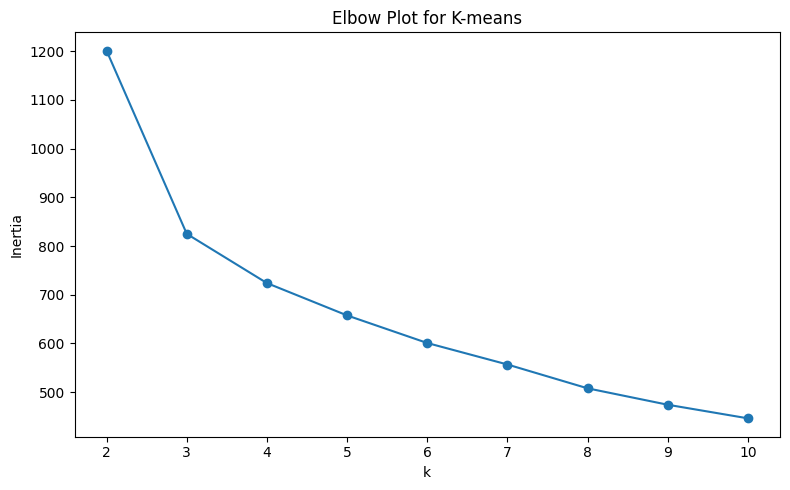

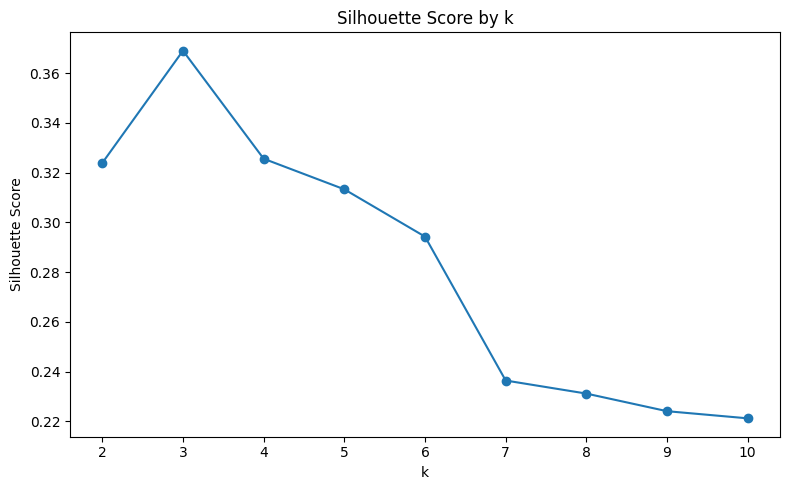

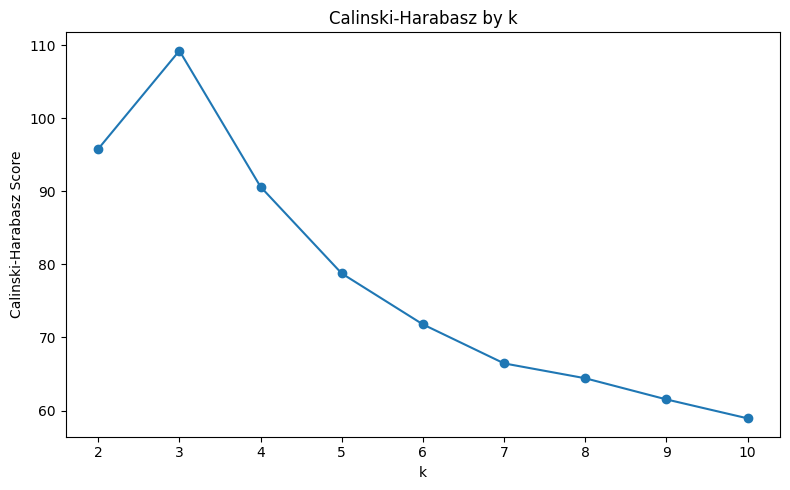

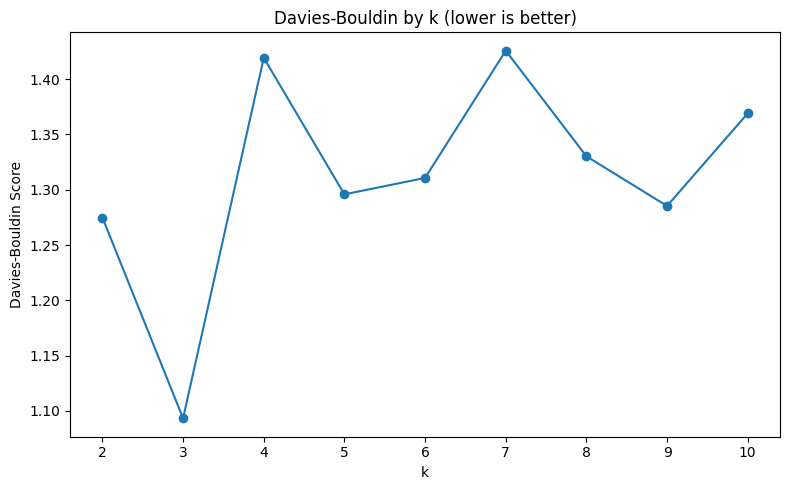

In [16]:
# K-means clustering on retained PCA components
k_values = range(2, 11)
kmeans_results = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X_pca)

    inertia = km.inertia_
    silhouette = silhouette_score(X_pca, labels)
    calinski = calinski_harabasz_score(X_pca, labels)
    davies = davies_bouldin_score(X_pca, labels)

    kmeans_results.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies
    })

kmeans_eval_df = pd.DataFrame(kmeans_results)
print(kmeans_eval_df.round(4))

# Plots for choosing k
plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval_df["k"], kmeans_eval_df["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Plot for K-means")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval_df["k"], kmeans_eval_df["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval_df["k"], kmeans_eval_df["calinski_harabasz"], marker="o")
plt.xlabel("k")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz by k")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval_df["k"], kmeans_eval_df["davies_bouldin"], marker="o")
plt.xlabel("k")
plt.ylabel("Davies-Bouldin Score")
plt.title("Davies-Bouldin by k (lower is better)")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

In [17]:
# Choose best k by highest silhouette as a simple default rule
best_k = int(kmeans_eval_df.loc[kmeans_eval_df["silhouette"].idxmax(), "k"])
print(f"\nBest k by silhouette score: {best_k}")

final_kmeans = KMeans(n_clusters=best_k, n_init=50, random_state=42)
final_labels = final_kmeans.fit_predict(X_pca)

clustered_df = df.copy()
clustered_df["kmeans_cluster"] = final_labels

print("\nCluster sizes for final k-means solution:")
print(clustered_df["kmeans_cluster"].value_counts().sort_index())

print("\nCluster means in original variable space:")
print(clustered_df.groupby("kmeans_cluster").mean(numeric_only=True).round(3))



Best k by silhouette score: 3

Cluster sizes for final k-means solution:
kmeans_cluster
0    65
1    51
2    62
Name: count, dtype: int64

Cluster means in original variable space:
                Alcohol  Malic_Acid    Ash  Ash_Alcanity  Magnesium  \
kmeans_cluster                                                        
0                12.251       1.897  2.231        20.063     92.738   
1                13.134       3.307  2.418        21.241     98.667   
2                13.677       1.998  2.466        17.463    107.968   

                Total_Phenols  Flavanoids  Nonflavanoid_Phenols  \
kmeans_cluster                                                    
0                       2.248       2.050                 0.358   
1                       1.684       0.819                 0.452   
2                       2.848       3.003                 0.292   

                Proanthocyanins  Color_Intensity    Hue  OD280   Proline  
kmeans_cluster                                     

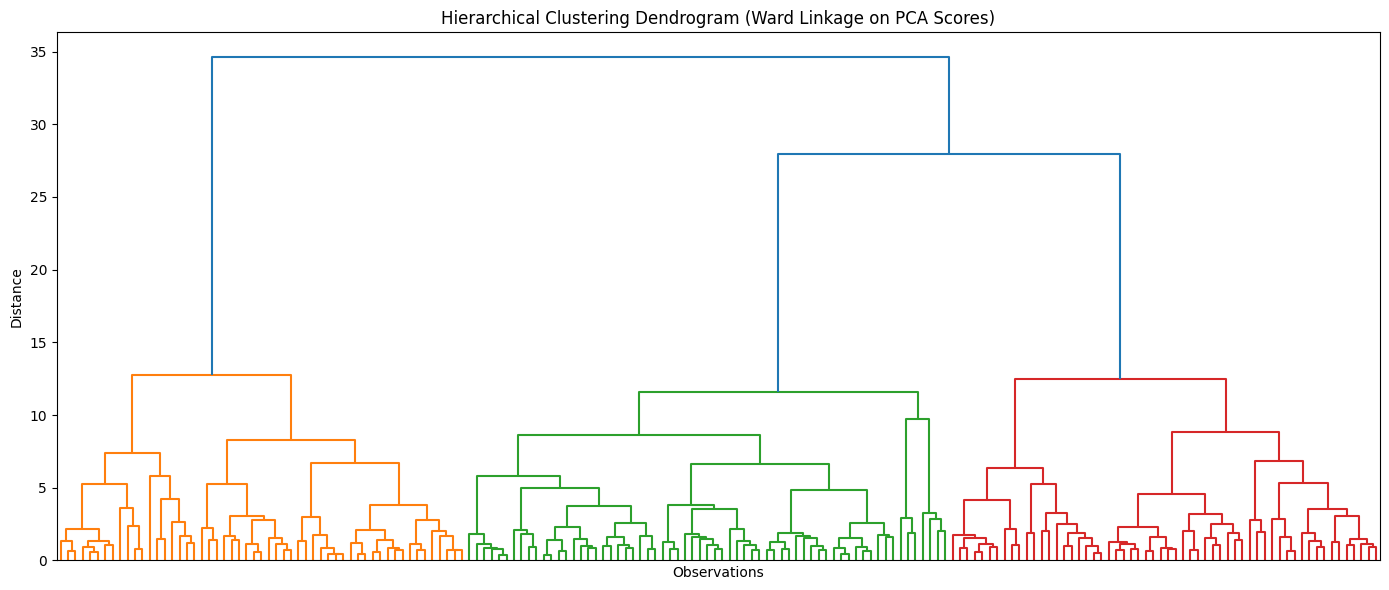

In [18]:
# Hierarchical clustering on retained PCA components
# Ward linkage
Z = linkage(X_pca, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage on PCA Scores)")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [19]:
# Cut hierarchical tree at number of clusters chosen by k-means
hc_labels = fcluster(Z, t=best_k, criterion="maxclust")

clustered_df["hier_cluster"] = hc_labels

print(f"\nCluster sizes for hierarchical clustering with {best_k} clusters:")
print(clustered_df["hier_cluster"].value_counts().sort_index())

print("\nHierarchical cluster means in original variable space:")
print(clustered_df.groupby("hier_cluster").mean(numeric_only=True).round(3))


Cluster sizes for hierarchical clustering with 3 clusters:
hier_cluster
1    55
2    65
3    58
Name: count, dtype: int64

Hierarchical cluster means in original variable space:
              Alcohol  Malic_Acid    Ash  Ash_Alcanity  Magnesium  \
hier_cluster                                                        
1              13.039       3.081  2.397        20.805    100.055   
2              13.613       1.958  2.449        17.422    108.908   
3              12.277       2.054  2.246        20.576     89.172   

              Total_Phenols  Flavanoids  Nonflavanoid_Phenols  \
hier_cluster                                                    
1                     1.695       0.830                 0.443   
2                     2.811       2.954                 0.292   
3                     2.286       2.131                 0.363   

              Proanthocyanins  Color_Intensity    Hue  OD280   Proline  \
hier_cluster                                                             
1

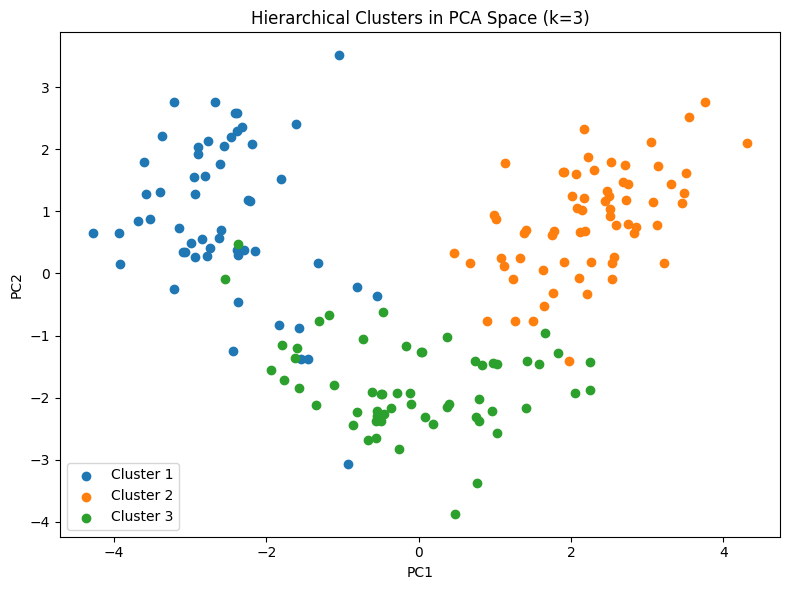

In [ ]:
# Plot hierarchical clusters in first two PCs
if X_pca.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    for cluster_id in sorted(np.unique(hc_labels)):
        mask = hc_labels == cluster_id
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {cluster_id}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Hierarchical Clusters in PCA Space (k={best_k})")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [21]:
# Compare k-means and hierarhcical solutions
comparison = pd.DataFrame({
    "kmeans_cluster": final_labels,
    "hier_cluster": hc_labels
})

print("\nCross-tabulation of k-means vs hierarchical clusters:")
print(pd.crosstab(comparison["kmeans_cluster"], comparison["hier_cluster"]))



Cross-tabulation of k-means vs hierarchical clusters:
hier_cluster     1   2   3
kmeans_cluster            
0                6   3  56
1               49   0   2
2                0  62   0
